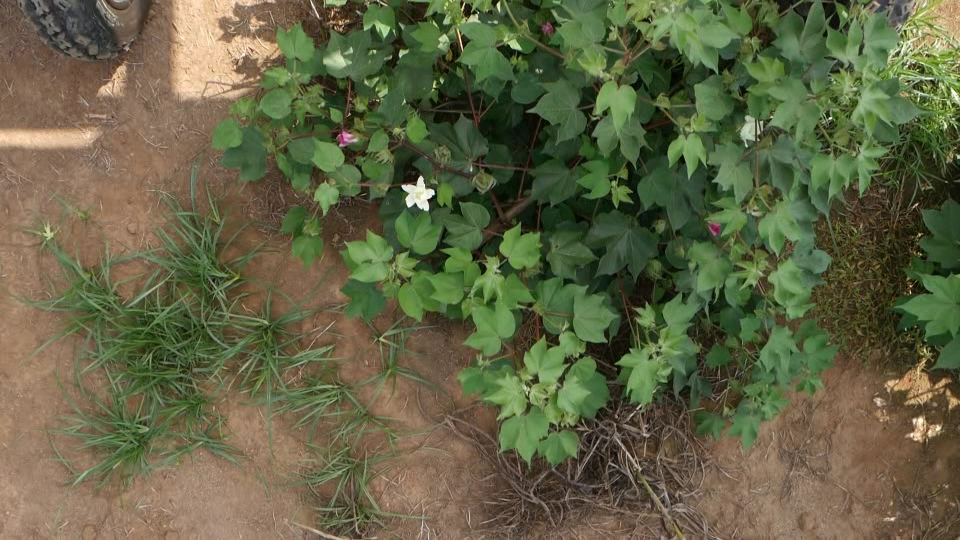

In [31]:
from PIL import Image

# Load a test image.
test_image = Image.open("test_images/flower_example.png").convert("RGB")
display(test_image)

In [2]:
import json
import numpy as np

data = json.dumps({"signature_name": "serving_default", "instances": np.array(test_image)[None, :, :, :].tolist()})
print('Data: {} ... {}'.format(data[:50], data[len(data)-52:]))

Data: {"signature_name": "serving_default", "instances": ... , [109, 94, 75], [133, 118, 98], [154, 139, 119]]]]}


In [4]:
import requests

headers = {"content-type": "application/json"}
json_response = requests.post('http://mars-controller.ad.ufl.edu:8501/v1/models/flower_detector:predict', data=data, headers=headers)
predictions = json.loads(json_response.text)["predictions"]

In [5]:
predictions[0]["input.to_tensor_1"]


[
    [0.436035156, 0.361328125, 0.0350036621, 0.061706543, 0.740722656],
    [0.859863281, 0.217285156, 0.0151062012, 0.0276794434, 0.000157356262],
    [0.996582031, 0.178955078, 0.00611877441, 0.0327453613, 8.43405724e-05],
    [0.561035156, 0.131347656, 0.0117797852, 0.0161132812, 7.59363174e-05],
    [0.687988281, 0.419189453, 0.0147705078, 0.0307159424, 6.16312e-05],
    [0.577636719, 0.0213470459, 0.00710296631, 0.0154876709, 5.4359436e-05],
    [0.696777344, 0.0166320801, 0.0123825073, 0.0184173584, 5.35845757e-05],
    [0.460205078, 0.282714844, 0.0176391602, 0.0312347412, 4.20808792e-05],
    [0.471435547, 0.00525665283, 0.0225830078, 0.00959014893, 2.38418579e-05],
    [0.00380706787, 0.0105896, 0.00796508789, 0.0233306885, 2.12192535e-05],
    [0.370849609, 0.110351562, 0.0129699707, 0.0338439941, 1.94907188e-05],
    [0.454833984, 0.155029297, 0.0121612549, 0.0258789062, 1.85966492e-05],
    [0.729980469, 0.00457000732, 0.020690918, 0.00899505615, 1.83582306e-05],
    [0.

In [6]:
# Create some random bounding boxes to test tracking.
detection_bounding_boxes = np.random.random((5, 4)).tolist()
tracklet_bounding_boxes = np.random.random((4, 4)).tolist()

appearance = np.array(predictions[0]["input.to_tensor_2"])
detection_appearance = appearance[:5].tolist()
tracklet_appearance = appearance[:4].tolist()

In [7]:
import json
import numpy as np

data = json.dumps({"signature_name": "serving_default", "inputs": {
    "detection_appearance_flat": [detection_appearance],
    "detection_appearance_row_lengths": [[5]],
    "tracklet_appearance_flat": [tracklet_appearance],
    "tracklet_appearance_row_lengths": [[4]],
    "detection_geometry_flat": [detection_bounding_boxes],
    "detection_geometry_row_lengths": [[5]],
    "tracklet_geometry_flat": [tracklet_bounding_boxes],
    "tracklet_geometry_row_lengths": [[4]],
}})
print('Data: {} ... {}'.format(data[:50], data[len(data)-52:]))

Data: {"signature_name": "serving_default", "inputs": {" ... 2377139]]], "tracklet_geometry_row_lengths": [[4]]}}


In [10]:
import requests

headers = {"content-type": "application/json"}
json_response = requests.post('http://mars-controller.ad.ufl.edu:8501/v1/models/flower_tracker:predict', data=data, headers=headers)
predictions = json.loads(json_response.text)["outputs"]

In [11]:
predictions


{
    'input.to_tensor': [
        [
            0.000600104453,
            0.024158515,
            0.277113348,
            0.00214827899,
            0.04345,
            0.653421,
            1.59321822e-09,
            0.774087667,
            0.00184160937,
            0.00103051134,
            0.0447803624,
            0.188631922,
            0.26240778,
            0.00779337622,
            0.712128699,
            7.91969294e-16,
            1.95695364e-07,
            0.0114251804,
            3.00886938e-07,
            0.000296094571,
            1.76235844e-05,
            0.926202893,
            0.0480018817,
            0.00187247538,
            0.736991763,
            0.193664387,
            0.00889862329,
            0.070618324,
            0.863767564,
            3.14464927
        ]
    ],
    'tf.cast_2': [30]
}

In [32]:
import grpc

# Create a channel that will be connected to the gRPC port of the container
channel = grpc.insecure_channel("mars-controller.ad.ufl.edu:8500")

In [33]:
from tensorflow_serving.apis import predict_pb2, prediction_service_pb2_grpc

# Create a stub made for prediction
# This stub will be used to send the gRPCrequest to the TF Server
stub = prediction_service_pb2_grpc.PredictionServiceStub(channel)

In [37]:
import tensorflow as tf

def predict_grpc_detect(data, input_name, stub):
    # Create a gRPC request made for prediction
    request = predict_pb2.PredictRequest()

    # Set the name of the model, for this use case it is "model"
    request.model_spec.name = "small_flower_detector"

    # Set which signature is used to format the gRPC query
    # here the default one "serving_default"
    request.model_spec.signature_name = "serving_default"

    # Set the input as the data
    # tf.make_tensor_proto turns a TensorFlow tensor into a Protobuf tensor
    request.inputs[input_name].CopyFrom(tf.make_tensor_proto(data.tolist()))

    # Send the gRPC request to the TF Server
    result = stub.Predict(request)
    return result

grpc_outputs = predict_grpc_detect(np.array(test_image)[None, :, :, :].astype(np.float32), "detections_frame", stub)
#detections = tf.make_ndarray(grpc_outputs.outputs["input.to_tensor_1"])
print(grpc_outputs.outputs)

{'input.to_tensor_4': dtype: DT_FLOAT
tensor_shape {
  dim {
    size: 1
  }
  dim {
    size: 15
  }
  dim {
    size: 392
  }
}
float_val: 10.347650527954102
float_val: -3.6459782123565674
float_val: -7.56170129776001
float_val: 8.307352066040039
float_val: 1.859373927116394
float_val: 2.326566696166992
float_val: -6.985146522521973
float_val: 7.322051525115967
float_val: 10.23703384399414
float_val: -3.7194297313690186
float_val: -6.956322193145752
float_val: 8.35092830657959
float_val: 2.1006715297698975
float_val: 2.6452109813690186
float_val: -6.979289531707764
float_val: 7.09722900390625
float_val: 10.126416206359863
float_val: -3.7928812503814697
float_val: -6.350943088531494
float_val: 8.39450454711914
float_val: 2.3419690132141113
float_val: 2.963855504989624
float_val: -6.9734320640563965
float_val: 6.872406482696533
float_val: 10.015799522399902
float_val: -3.8663330078125
float_val: -5.745563507080078
float_val: 8.438080787658691
float_val: 2.583266496658325
float_val: 3.2

In [35]:
detections


array([[[4.3603516e-01, 3.6132812e-01, 3.5003662e-02, 6.1706543e-02,
         7.4072266e-01],
        [8.5986328e-01, 2.1728516e-01, 1.5106201e-02, 2.7679443e-02,
         1.5735626e-04],
        [9.9658203e-01, 1.7895508e-01, 6.1187744e-03, 3.2745361e-02,
         8.4340572e-05],
        [5.6103516e-01, 1.3134766e-01, 1.1779785e-02, 1.6113281e-02,
         7.5936317e-05],
        [6.8798828e-01, 4.1918945e-01, 1.4770508e-02, 3.0715942e-02,
         6.1631203e-05],
        [5.7763672e-01, 2.1347046e-02, 7.1029663e-03, 1.5487671e-02,
         5.4359436e-05],
        [6.9677734e-01, 1.6632080e-02, 1.2382507e-02, 1.8417358e-02,
         5.3584576e-05],
        [4.6020508e-01, 2.8271484e-01, 1.7639160e-02, 3.1234741e-02,
         4.2080879e-05],
        [4.7143555e-01, 5.2566528e-03, 2.2583008e-02, 9.5901489e-03,
         2.3841858e-05],
        [3.8070679e-03, 1.0589600e-02, 7.9650879e-03, 2.3330688e-02,
         2.1219254e-05],
        [3.7084961e-01, 1.1035156e-01, 1.2969971e-02, 3.384

In [18]:
import tensorflow as tf

def predict_grpc_track(input_dict, stub):
    # Create a gRPC request made for prediction
    request = predict_pb2.PredictRequest()

    # Set the name of the model, for this use case it is "model"
    request.model_spec.name = "flower_tracker"

    # Set which signature is used to format the gRPC query
    # here the default one "serving_default"
    request.model_spec.signature_name = "serving_default"

    # Set the input as the data
    for input_name, input_data in input_dict.items():
        # tf.make_tensor_proto turns a TensorFlow tensor into a Protobuf tensor
        request.inputs[input_name].CopyFrom(tf.make_tensor_proto(input_data))

    # Send the gRPC request to the TF Server
    result = stub.Predict(request)
    return result

input_dict = {
    "detection_appearance_flat": [detection_appearance],
    "detection_appearance_row_lengths": [[5]],
    "tracklet_appearance_flat": [tracklet_appearance],
    "tracklet_appearance_row_lengths": [[4]],
    "detection_geometry_flat": [detection_bounding_boxes],
    "detection_geometry_row_lengths": [[5]],
    "tracklet_geometry_flat": [tracklet_bounding_boxes],
    "tracklet_geometry_row_lengths": [[4]]
}

grpc_outputs = predict_grpc_track(input_dict, stub)
sinkhorn = tf.make_ndarray(grpc_outputs.outputs["input.to_tensor"])

In [19]:
sinkhorn


array([[6.0010445e-04, 2.4158515e-02, 2.7711335e-01, 2.1482790e-03,
        4.3450002e-02, 6.5342098e-01, 1.5932182e-09, 7.7408767e-01,
        1.8416094e-03, 1.0305113e-03, 4.4780362e-02, 1.8863192e-01,
        2.6240778e-01, 7.7933762e-03, 7.1212870e-01, 7.9196929e-16,
        1.9569536e-07, 1.1425180e-02, 3.0088694e-07, 2.9609457e-04,
        1.7623584e-05, 9.2620289e-01, 4.8001882e-02, 1.8724754e-03,
        7.3699176e-01, 1.9366439e-01, 8.8986233e-03, 7.0618324e-02,
        8.6376756e-01, 3.1446493e+00]], dtype=float32)